In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# import matplotlib.cm as cm

import geopandas as gpd

import matplotlib as mpl

import cartopy.feature as cfeature

import cartopy.crs as ccrs
import matplotlib.colors as colors

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("njdep_sf_gam.csv")

In [3]:
df

,ID,year,STRATUM,YRMODA,TIME,MINOUT,STARTDEPTH,ENDDEPTH,MINDEPTH,MAXDEPTH,...,drho,location,n_s,decade,para_weight,para,para_cpue,para1,x_dist,y_dist
0,19901001,1990,20,1990-02-06,855,20.5,16.00,18.000,16.000,18.00,...,0.002676,Offshore,South,1990,0.00,0.0,0.00,0.0,11.203525,102.299765
1,19901002,1990,19,1990-02-06,1042,19.5,18.00,16.000,15.000,18.00,...,0.004103,Midshore,South,1990,0.00,0.0,0.00,0.0,10.876190,94.776159
2,19901003,1990,19,1990-02-06,1213,20.0,10.00,9.000,9.000,12.00,...,0.002938,Midshore,South,1990,0.00,0.0,0.00,0.0,4.678182,96.605073
3,19901004,1990,23,1990-02-07,905,20.0,20.00,24.000,20.000,26.00,...,-0.043777,Offshore,South,1990,0.00,0.0,0.00,0.0,18.809184,69.377030
4,19901005,1990,22,1990-02-07,1040,20.7,20.00,18.000,18.000,21.00,...,-0.018268,Midshore,South,1990,0.00,0.0,0.00,0.0,17.353040,54.727214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5536,20195144,2019,17,2019-11-10,1516,20.0,26.84,25.010,24.705,26.84,...,0.007287,Offshore,North,2010,1.49,1.0,0.05,1.0,17.022285,146.788868
5537,20195145,2019,17,2019-11-10,1627,20.0,22.57,23.180,NaN,NaN,...,0.008632,Offshore,North,2010,0.00,0.0,0.00,0.0,15.524259,155.089621
5538,20195146,2019,17,2019-11-11,657,20.0,21.96,24.400,NaN,NaN,...,0.039465,Offshore,North,2010,0.00,0.0,0.00,0.0,14.187835,169.419804
5539,20195147,2019,16,2019-11-11,858,20.0,17.69,15.860,NaN,NaN,...,0.044501,Midshore,North,2010,6.85,21.0,1.05,1.0,2.572735,178.016013


##### Mean CPUE over years

In [4]:
january = df.groupby('cruise').get_group(1).groupby('year').para_cpue
april = df.groupby('cruise').get_group(2).groupby('year').para_cpue
august = df.groupby('cruise').get_group(4).groupby('year').para_cpue
june = df.groupby('cruise').get_group(3).groupby('year').para_cpue
october = df.groupby('cruise').get_group(5).groupby('year').para_cpue

dfyear = df.groupby('year')

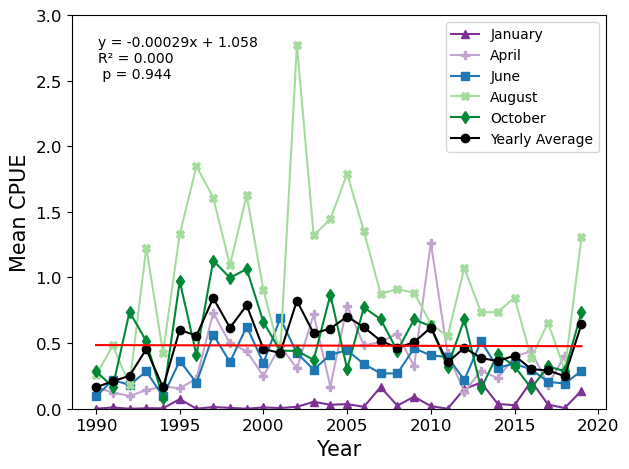

In [27]:
###. Survey Annual Averages
months_df=[january,april,june,august,october]
months=["January","April","June","August","October"]
color = ['#7b3294','#c2a5cf',"#1f78b4","#a6dba0","#008837"]
marker = ['^','P','s','X','d']
# color1 = ['#1f78b4','#33a02c']
# text_y = [0.95, 0.80] 

for i in range(5): 
    monthly = months_df[i].mean().reset_index()

    plt.plot(monthly["year"], monthly["para_cpue"],marker=marker[i],color=color[i],label=months[i])
    plt.xticks(size=12)
    plt.yticks(size=12)
    plt.xlabel('Year',size=15)
    plt.ylabel('Mean CPUE',size=15)

yearly = dfyear["para_cpue"].mean().reset_index()   # gives columns: year, cpue

slope, intercept, r, p, stderr = linregress(yearly["year"], yearly["para_cpue"])

plt.plot(yearly["year"], yearly["para_cpue"],marker='o',color='k',label="Yearly Average")
plt.plot(yearly["year"], intercept + (slope * yearly["year"]),color='red')
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel('Year',size=15)
plt.ylabel('Mean CPUE',size=15)

eq_text = f"y = {slope:.5f}x + {intercept:.3f} \nR² = {r**2:.3f} \n p = {p:.3f}"

plt.text(
    0.05, 0.95, 
    eq_text, 
    transform=plt.gca().transAxes, 
    verticalalignment='top'
);
plt.legend(loc='upper right')

plt.ylim(0,3)
plt.tight_layout()

#### GAM Predicted Index

In [6]:
gam_pred = pd.read_csv('predicted_index.csv')

In [ ]:
predicted = gam_pred[['cruise','year','predicted']]
raw_data = df.groupby(['year','cruise'])["para_cpue"].mean().reset_index()

In [32]:
result = predicted.merge(raw_data,on=['year', 'cruise'])

result['relative_error'] = ((result['predicted'] - result['para_cpue'])/ result['para_cpue'])

result['diff'] = ((result['predicted'] - result['para_cpue']))

result['percent_error'] = ((abs(result['predicted'] - result['para_cpue'])/ result['para_cpue'])*100)

In [34]:
result['relative_error'] = result['relative_error'].replace(np.inf, np.nan)

In [35]:
result

,cruise,year,predicted,para_cpue,relative_error,diff,percent_error
0,1,1990,0.007356,0.000000,NaN,0.007356,inf
1,2,1990,0.070543,0.164534,-0.571257,-0.093991,57.125740
2,3,1990,0.083916,0.093997,-0.107247,-0.010081,10.724714
3,4,1990,0.082737,0.253442,-0.673548,-0.170705,67.354765
4,5,1990,0.289356,0.285290,0.014251,0.004066,1.425111
...,...,...,...,...,...,...,...
144,5,2018,0.193178,0.285923,-0.324369,-0.092744,32.436884
145,1,2019,0.059123,0.137931,-0.571359,-0.078808,57.135923
146,3,2019,0.156761,0.288462,-0.456562,-0.131701,45.656183
147,4,2019,0.394808,1.306140,-0.697729,-0.911332,69.772915


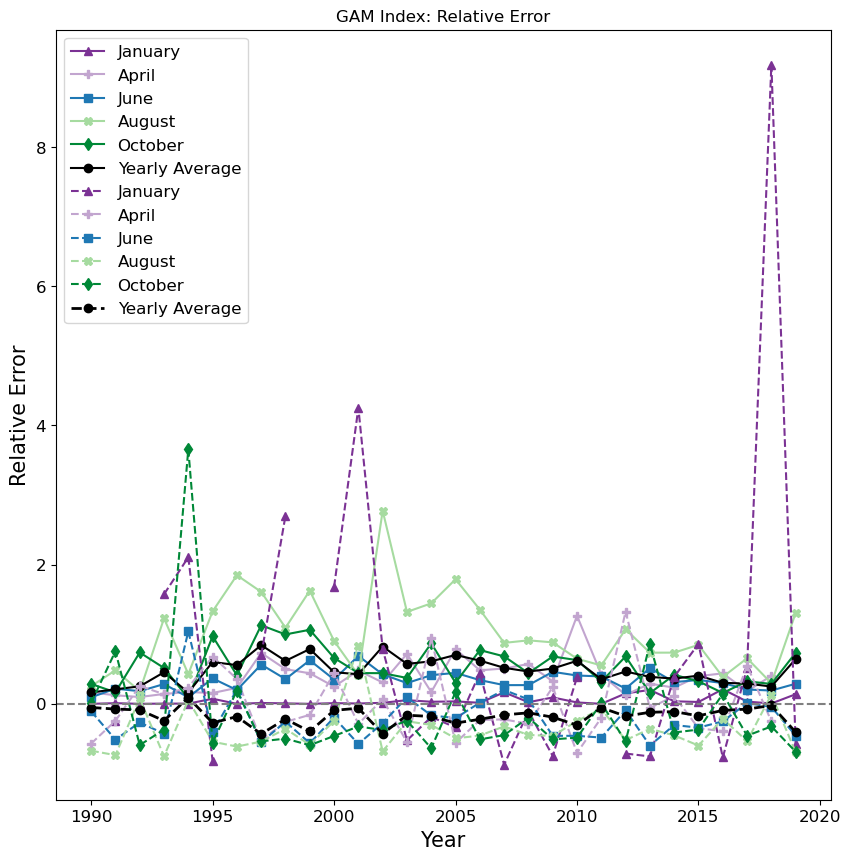

In [65]:
fig,ax = plt.subplots(figsize=(10,10))

for i in range(5): 
    monthly = months_df[i].mean().reset_index()

    plt.plot(monthly["year"], monthly["para_cpue"],marker=marker[i],color=color[i],label=months[i])
    plt.xticks(size=12)
    plt.yticks(size=12)
    plt.xlabel('Year',size=15)
    plt.ylabel('Mean CPUE',size=15)

yearly = df.groupby("year")["para_cpue"].mean().reset_index()   # gives columns: year, cpue

plt.plot(yearly["year"], yearly["para_cpue"],marker='o',color='k',label="Yearly Average")

for i in range(5): 
    monthly = result.groupby('cruise').get_group(i+1)
    plt.plot(monthly["year"], monthly["relative_error"],marker=marker[i],color=color[i],label=months[i],ls='--')


yearly = result.groupby('year')['diff'].mean(skipna=True)

plt.plot(yearly.index,yearly.values,color='k',lw=2,ls="--",marker='o',label='Yearly Average')
plt.axhline(0, color='grey',ls='--')

plt.legend(fontsize=12)
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel('Year',size=15)
plt.ylabel('Relative Error',size=15)

plt.title("GAM Index: Relative Error");

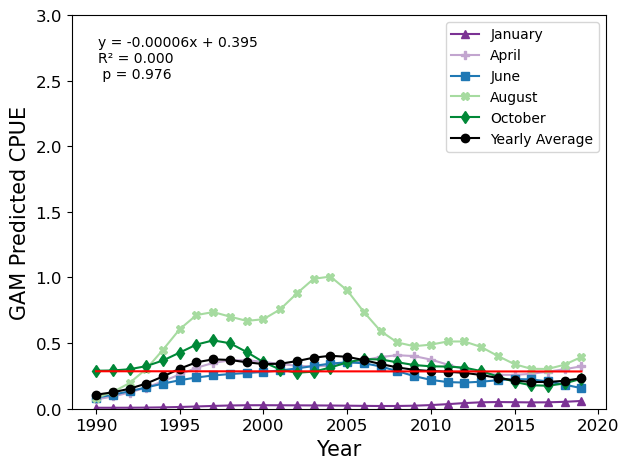

In [ ]:
#### GAM Predicted CPUE
months=["January","April","June","August","October"]
color = ['#7b3294','#c2a5cf',"#1f78b4","#a6dba0","#008837"]
marker = ['^','P','s','X','d']
# color1 = ['#1f78b4','#33a02c']
# text_y = [0.95, 0.80] 

for i in range(5): 
    monthly = gam_pred.groupby('cruise').get_group(i+1)
    plt.plot(monthly["year"], monthly["predicted"],marker=marker[i],color=color[i],label=months[i])
    plt.xticks(size=12)
    plt.yticks(size=12)
    plt.xlabel('Year',size=15)
    plt.ylabel('GAM Predicted CPUE',size=15)

yearly = gam_pred.groupby('year').predicted.mean()

slope, intercept, r, p, stderr = linregress(yearly.index, yearly.values)

plt.plot(yearly.index, yearly.values,marker='o',color='k',label="Yearly Average")
plt.plot(yearly.index, intercept + (slope * yearly.index),color='red')
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel('Year',size=15)
plt.ylabel('GAM Predicted CPUE',size=15)

eq_text = f"y = {slope:.5f}x + {intercept:.3f} \nR² = {r**2:.3f} \n p = {p:.3f}"

plt.text(
    0.05, 0.95, 
    eq_text, 
    transform=plt.gca().transAxes, 
    verticalalignment='top'
);

plt.ylim(0,3)
plt.legend(loc='upper right')
plt.tight_layout()


Text(0.5, 1.0, 'GAM Predicted CPUE and Raw Data')

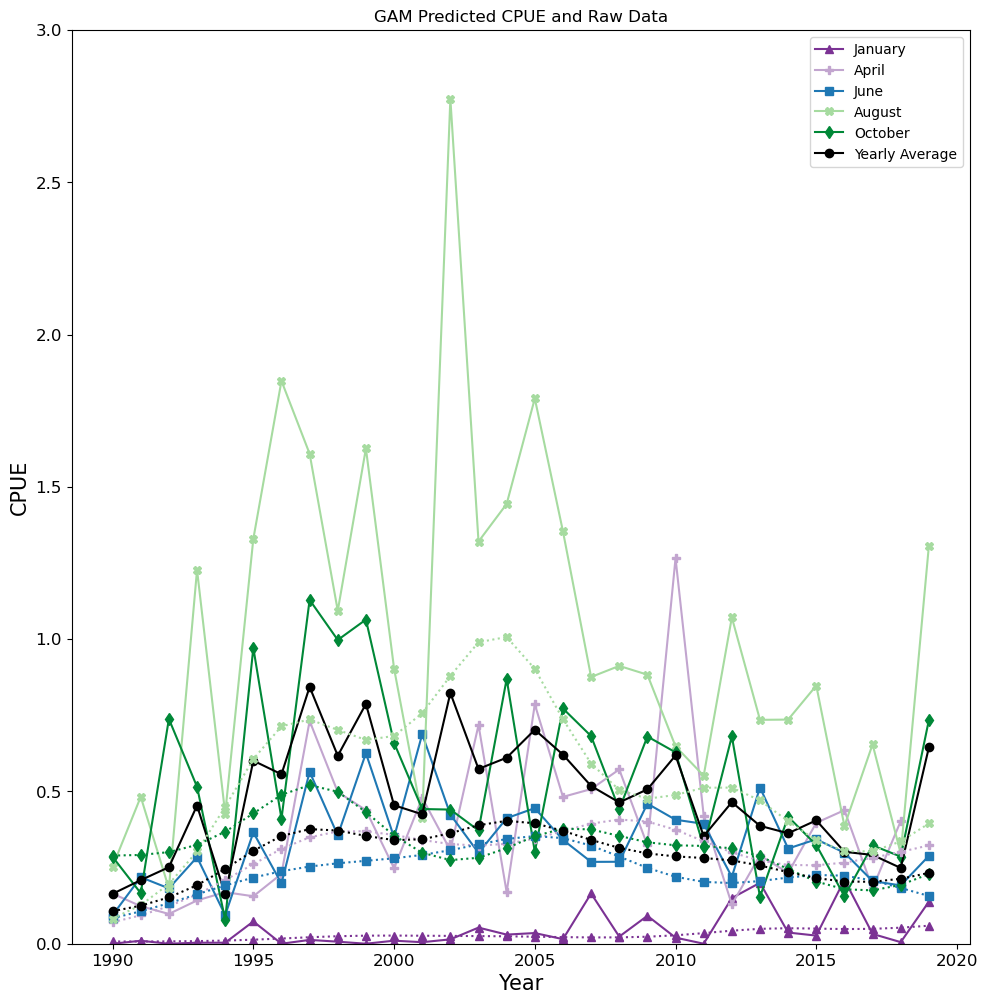

In [ ]:
#### GAM Predicted CPUE and Raw Data
months_df=[january,april,june,august,october]
months=["January","April","June","August","October"]
color = ['#7b3294','#c2a5cf',"#1f78b4","#a6dba0","#008837"]
marker = ['^','P','s','X','d']
# color1 = ['#1f78b4','#33a02c']
# text_y = [0.95, 0.80] 

plt.figure(figsize=(10,10))
for i in range(5): 
    monthly = months_df[i].mean().reset_index()

    plt.plot(monthly["year"], monthly["para_cpue"],marker=marker[i],color=color[i],label=months[i])
    plt.xticks(size=12)
    plt.yticks(size=12)
    plt.xlabel('Year',size=15)
    plt.ylabel('Mean CPUE',size=15)

yearly = dfyear["para_cpue"].mean().reset_index()   # gives columns: year, cpue

slope, intercept, r, p, stderr = linregress(yearly["year"], yearly["para_cpue"])

plt.plot(yearly["year"], yearly["para_cpue"],marker='o',color='k',label="Yearly Average")

plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel('Year',size=15)
plt.ylabel('Mean CPUE',size=15)


for i in range(5): 
    monthly = gam_pred.groupby('cruise').get_group(i+1)
    plt.plot(monthly["year"], monthly["predicted"],marker=marker[i],color=color[i],ls='dotted')
    plt.xticks(size=12)
    plt.yticks(size=12)
    plt.xlabel('Year',size=15)
    plt.ylabel('GAM Predicted CPUE',size=15)

yearly = gam_pred.groupby('year').predicted.mean()

plt.plot(yearly.index, yearly.values,marker='o',color='k',ls='dotted')

plt.xticks(size=12)
plt.yticks(size=12)

plt.ylabel('CPUE',size=15)

plt.legend(loc='upper right')

plt.ylim(0,3)
plt.tight_layout()
plt.title("GAM Predicted CPUE and Raw Data");

# plt.savefig('gam_predicted_index_oneplot.jpeg',dpi=300, bbox_inches='tight')


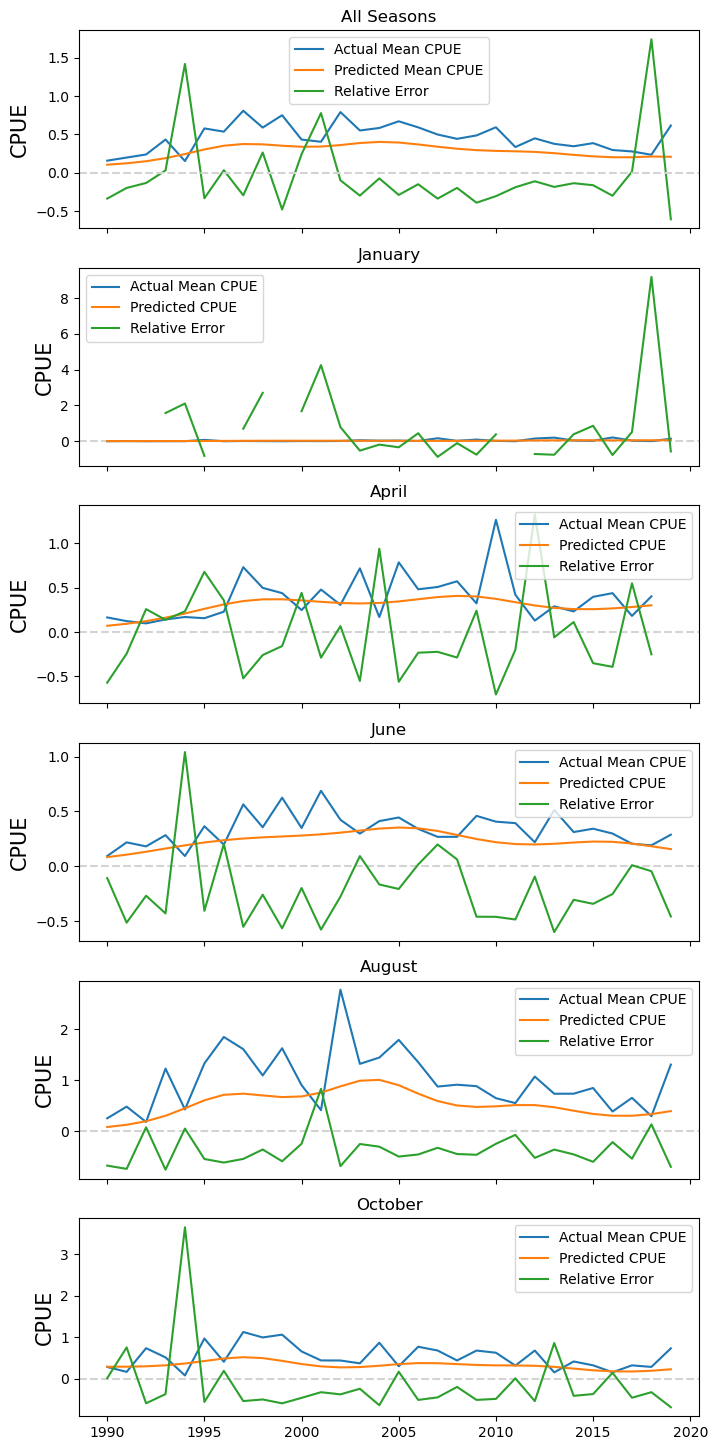

In [64]:
months=["January","April","June","August","October"]

fig, ax = plt.subplots(6,figsize=(8,18),sharex=True)

ax[0].plot(result.groupby('year')['para_cpue'].mean(),label="Actual Mean CPUE")
ax[0].plot(result.groupby('year')['predicted'].mean(),label="Predicted Mean CPUE")
ax[0].plot(result.groupby('year')['relative_error'].mean(),label="Relative Error")

ax[0].legend()
ax[0].axhline(0,color='lightgray',ls='--')

ax[0].set_title("All Seasons")
ax[0].set_ylabel('CPUE',size=15)

for i in range(5): 
    monthly = result.groupby('cruise').get_group(i+1)

    ax[i+1].plot(monthly["year"], monthly["para_cpue"],label="Actual Mean CPUE")
    ax[i+1].plot(monthly["year"], monthly["predicted"],label="Predicted CPUE")
    ax[i+1].plot(monthly["year"], monthly["relative_error"],label="Relative Error")

    ax[i+1].set_title(months[i])

    ax[i+1].set_ylabel('CPUE',size=15)
    ax[i+1].legend()
    ax[i+1].axhline(0,color='lightgray',ls='--',zorder=-9)

plt.savefig('gam_relative_error.jpeg',dpi=300, bbox_inches='tight') 

##### Creating Anomalies for April and August

In [46]:
april_cruise = df.groupby("cruise").get_group(2)
aug_cruise   = df.groupby("cruise").get_group(4)


In [47]:
df.groupby("cruise").para_cpue.mean()

april_mean = 0.383969
aug_mean = 0.999358

df.groupby("cruise").para_cpue.mean()

cruise
1    0.045381
2    0.383969
3    0.336404
4    0.999358
5    0.535916
Name: para_cpue, dtype: float64

In [48]:
means = [april_mean, aug_mean]
cruises = [april_cruise,aug_cruise]
month = ["April","Aug"]

for i in range(2):
    cruises[i].loc[:, "para_anom"] = cruises[i]["para_cpue"] - means[i];

##### Temperature

In [49]:
df.groupby('cruise').TEMPBOT.mean()

april_mean = 7.673633
aug_mean = 18.098838

df.groupby('cruise').TEMPBOT.mean()

cruise
1     5.118323
2     7.673633
3    13.976207
4    18.098838
5    16.426093
Name: TEMPBOT, dtype: float64

In [50]:
means = [april_mean, aug_mean,]
cruises = [april_cruise,aug_cruise,]
month = ["April","Aug"]

for i in range(2):
    cruises[i].loc[:, "temp_anom"] = cruises[i]["TEMPBOT"] - means[i];

##### Salinity

In [51]:
df.groupby('cruise').SALBOT.mean()

april_mean = 31.802151
aug_mean = 31.519365

df.groupby('cruise').SALBOT.mean()

cruise
1    31.867553
2    31.802151
3    31.527042
4    31.519365
5    31.789509
Name: SALBOT, dtype: float64

In [52]:
means = [april_mean, aug_mean]
cruises = [april_cruise,aug_cruise]
month = ["April","Aug"]

for i in range(2):
    cruises[i].loc[:, "sal_anom"] = cruises[i]["SALBOT"] - means[i];

##### drho (bot temp - surf temp)/depth

In [53]:
df.groupby('cruise').drho.mean()

april_mean = 0.093903
aug_mean = 0.108338
df.groupby('cruise').drho.mean()

cruise
1    0.056860
2    0.121934
3    0.177722
4    0.169298
5    0.032457
Name: drho, dtype: float64

In [54]:
means = [april_mean, aug_mean]
cruises = [april_cruise,aug_cruise]
month = ["April","Aug",]

for i in range(2):
    cruises[i].loc[:, "drho_anom"] = cruises[i]["drho"] - means[i];

##### delta rho (bot temp - surf temp)

In [55]:
df.groupby('cruise').delta_rho.mean()

april_mean = 1.395371
aug_mean = 1.846872

df.groupby('cruise').delta_rho.mean()

cruise
1    0.575951
2    1.395371
3    2.141296
4    1.846872
5    0.415177
Name: delta_rho, dtype: float64

In [56]:
means = [april_mean, aug_mean]
cruises = [april_cruise,aug_cruise]
month = ["April","Aug"]

for i in range(2):
    cruises[i].loc[:, "deltarho_anom"] = cruises[i]["delta_rho"] - means[i];

#### Decadal Means

In [57]:
## April mean
y90_april = april_cruise.groupby("decade").get_group(1990)
y2k_april = april_cruise.groupby("decade").get_group(2000)
y210_april= april_cruise.groupby("decade").get_group(2010)

decades = [y90_april,y2k_april,y210_april]
para_means_ap = []
temp_means_ap = []
sal_means_ap = []
drho_means_ap = []
deltarho_means_ap = []

for i in range(len(decades)):
    para_mean = decades[i].para_cpue.mean()
    temp_mean = decades[i].TEMPBOT.mean()
    sal_mean = decades[i].SALBOT.mean()
    drho_mean = decades[i].drho.mean()
    deltarho_mean = decades[i].delta_rho.mean()
    

    para_means_ap.append(para_mean)
    temp_means_ap.append(temp_mean)
    sal_means_ap.append(sal_mean)
    drho_means_ap.append(drho_mean)
    deltarho_means_ap.append(deltarho_mean)

In [58]:
## April std
y90_april = april_cruise.groupby("decade").get_group(1990)
y2k_april = april_cruise.groupby("decade").get_group(2000)
y210_april= april_cruise.groupby("decade").get_group(2010)

decades = [y90_april,y2k_april,y210_april]
para_stds_ap = []
temp_stds_ap = []
sal_stds_ap = []
drho_stds_ap = []
deltarho_stds_ap = []

for i in range(len(decades)):
    para_std = decades[i].para_cpue.std()
    temp_std = decades[i].TEMPBOT.std()
    sal_std = decades[i].SALBOT.std()
    drho_std = decades[i].drho.std()
    deltarho_std = decades[i].delta_rho.std()
    

    para_stds_ap.append(para_std)
    temp_stds_ap.append(temp_std)
    sal_stds_ap.append(sal_std)
    drho_stds_ap.append(drho_std)
    deltarho_stds_ap.append(deltarho_std)

In [59]:
## August mean
y90_aug = aug_cruise.groupby("decade").get_group(1990)
y2k_aug = aug_cruise.groupby("decade").get_group(2000)
y210_aug= aug_cruise.groupby("decade").get_group(2010)

decades = [y90_aug,y2k_aug,y210_aug]
para_means_aug = []
temp_means_aug = []
sal_means_aug = []
drho_means_aug = []
deltarho_means_aug = []


for i in range(len(decades)):
    para_mean = decades[i].para_cpue.mean()
    temp_mean = decades[i].TEMPBOT.mean()
    sal_mean = decades[i].SALBOT.mean()
    drho_mean = decades[i].drho.mean()
    deltarho_mean = decades[i].delta_rho.mean()
    

    para_means_aug.append(para_mean)
    temp_means_aug.append(temp_mean)
    sal_means_aug.append(sal_mean)
    drho_means_aug.append(drho_mean)
    deltarho_means_aug.append(deltarho_mean)
    

In [60]:
## August std
y90_aug = aug_cruise.groupby("decade").get_group(1990)
y2k_aug = aug_cruise.groupby("decade").get_group(2000)
y210_aug= aug_cruise.groupby("decade").get_group(2010)

decades = [y90_aug,y2k_aug,y210_aug]
para_stds_aug = []
temp_stds_aug = []
sal_stds_aug = []
drho_stds_aug = []
deltarho_stds_aug = []


for i in range(len(decades)):
    para_std = decades[i].para_cpue.std()
    temp_std = decades[i].TEMPBOT.std()
    sal_std = decades[i].SALBOT.std()
    drho_std = decades[i].drho.std()
    deltarho_std = decades[i].delta_rho.std()
    

    para_stds_aug.append(para_std)
    temp_stds_aug.append(temp_std)
    sal_stds_aug.append(sal_std)
    drho_stds_aug.append(drho_std)
    deltarho_stds_aug.append(deltarho_std)
    

In [61]:
data = [para_means_ap,para_stds_ap, temp_means_ap,temp_stds_ap, sal_means_ap,sal_stds_ap,drho_means_ap,drho_stds_ap,deltarho_means_ap,deltarho_stds_ap,
        para_means_aug,para_stds_aug, temp_means_aug,temp_stds_aug, sal_means_aug,sal_stds_aug,drho_means_aug,drho_stds_aug,deltarho_means_aug,deltarho_stds_aug]

columns = ["1990s Mean","2000s Mean","2010s Mean"]

rows = ["SF CPUE April Mean", "SF CPUE April STD", "Bottom Temp April Mean","Bottom Temp April STD","Bottom Sal April Mean",
        "Bottom Sal April STD", "drho April Mean","drho April STD","deltarho April Mean","deltarho April STD",
        "SF CPUE Aug Mean", "SF CPUE Aug STD", "Bottom Temp Aug Mean","Bottom Temp Aug STD","Bottom Sal Aug Mean",
        "Bottom Sal Aug STD", "drho Aug Mean","drho Aug STD","deltarho Aug Mean","deltarho Aug STD"]

anom_df= pd.DataFrame(data=data, 
                      columns=columns,
                      index=rows)

In [62]:
anom_df

,1990s Mean,2000s Mean,2010s Mean
SF CPUE April Mean,0.278843,0.459196,0.415662
SF CPUE April STD,0.534904,0.660287,0.630760
Bottom Temp April Mean,7.145833,7.828718,8.083409
Bottom Temp April STD,1.668518,1.823891,1.561030
Bottom Sal April Mean,31.619271,31.691026,32.129426
Bottom Sal April STD,1.456844,1.092577,0.940877
drho April Mean,0.114702,0.140462,0.109945
drho April STD,0.159612,0.220604,0.144726
deltarho April Mean,1.525661,1.465125,1.173167
deltarho April STD,2.173794,1.879834,1.496272


In [63]:
df.delta_rho.describe()

count    5521.000000
mean        1.312319
std         1.601507
min        -3.700030
25%         0.164342
50%         0.718360
75%         2.113830
max        25.589595
Name: delta_rho, dtype: float64

#### Spatial Plots

In [64]:
### Fixing the shapefile to be in the right projection
fname = 'Ocean_Trawl_Strata_20210128.shp'
nj = gpd.read_file(fname)

# Check the current CRS
# print("Original CRS:", nj.crs)

# If it's not in EPSG:4326, convert it
if nj.crs is None:
    print("Warning: No CRS found! Assigning EPSG:4326 as a guess.")
    nj = nj.set_crs("EPSG:4326")  # Assign if missing

elif nj.crs.to_string() != "EPSG:4326":
    nj = nj.to_crs("EPSG:4326")  # Convert projection

# print("Updated CRS:", nj.crs)

##### April

In [65]:
y90_april = april_cruise.groupby("decade").get_group(1990)
y2k_april = april_cruise.groupby("decade").get_group(2000)
y210_april= april_cruise.groupby("decade").get_group(2010)

In [66]:
april90s_mean = y90_april.groupby('STRATUM')[["para_cpue",'temp_anom',"sal_anom",'deltarho_anom']].mean()
april00s_mean = y2k_april.groupby('STRATUM')[["para_cpue",'temp_anom',"sal_anom",'deltarho_anom']].mean()
april10s_mean = y210_april.groupby('STRATUM')[["para_cpue",'temp_anom',"sal_anom",'deltarho_anom']].mean()
april_mean = april_cruise.groupby('STRATUM')[["para_cpue",'temp_anom',"sal_anom",'deltarho_anom']].mean()

In [67]:
nj90_ap = nj.merge(april90s_mean, on="STRATUM",how='left')
nj00_ap = nj.merge(april00s_mean, on="STRATUM",how='left')
nj10_ap = nj.merge(april10s_mean, on="STRATUM",how='left')
nj_aprilall = nj.merge(april_mean,on="STRATUM",how='left')

##### Getting SF point sizes to scale

In [68]:
# Option 1: Custom bin edges
bin_edges = [0, 0.1, 0.5, 1, 5, 10, 17.5]
size_labels = [1, 20, 30, 50, 70, 100]  # These are point sizes

catch_bins = pd.cut(df.para_cpue, bins=bin_edges, labels=size_labels, include_lowest=True)
point_sizes = catch_bins.astype(float)  # Convert labels to float


Text(0.5, 1.0, 'Scaled Point Sizes by Catch')

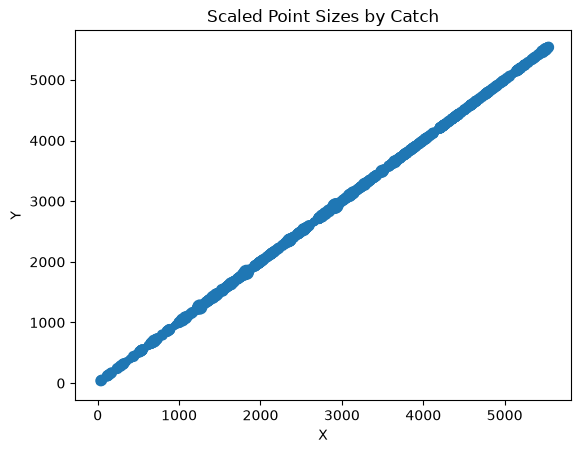

In [69]:
# Dummy coordinates for plotting
x = range(len(df.para_cpue))
y = range(len(df.para_cpue))

plt.scatter(x, y, s=point_sizes)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scaled Point Sizes by Catch')

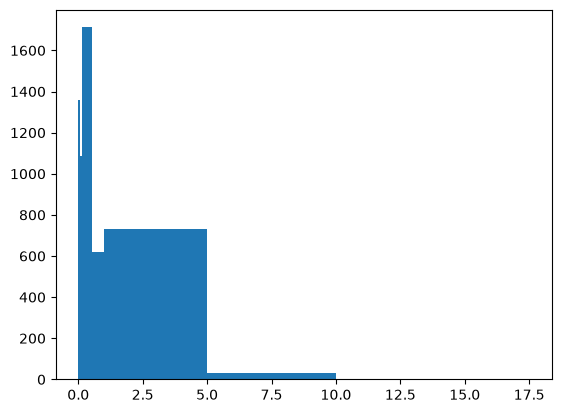

In [70]:
bin_edges = [0,0.05, 0.15, 0.55, 1, 5, 10,15,17.5]
bin_edges = [0,0.05, 0.15, 0.55, 1, 5, 10, 17.5]
# sns.boxplot(df.para_cpue,showfliers=False)
plt.hist(df.para_cpue,bins=bin_edges);

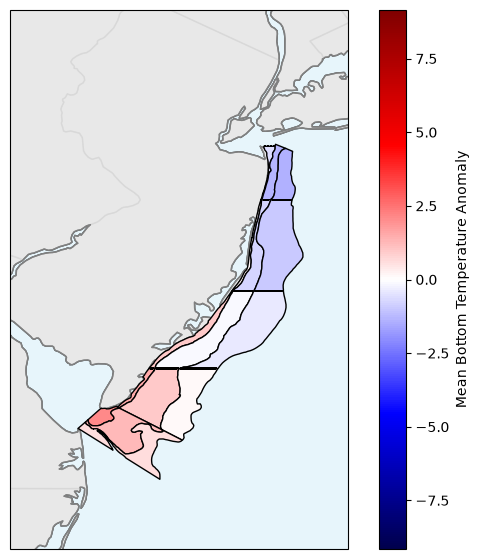

In [ ]:
##  TEST Colormap by Stratum Number 
## Create a colormap based on a variable, e.g., 'temp_anom'
norm = colors.Normalize(vmin=-9.15, vmax=9.15)
cmap = plt.get_cmap('seismic')

# Create plot
fig, ax = plt.subplots(figsize=(20, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot each geometry individually with color based on the value
for i, geom in enumerate(nj.geometry):
    value = nj00_ap.loc[i, 'temp_anom']
    color = cmap(norm(value))
    ax.add_geometries([geom], crs=ccrs.PlateCarree(), facecolor=color, edgecolor='black', zorder=1000)

# Add coastlines
ax.coastlines()

# Set extent
ax.set_extent([-75.5, -73.5, 38.3, 41.5])
ax.add_feature(cfeature.STATES, color="lightgrey", alpha=0.5)
ax.add_feature(cfeature.OCEAN, color="skyblue", alpha=0.2)
ax.add_feature(cfeature.COASTLINE, color='grey')

# Add colorbar
sm = plt.ScalarMappable(cmap=cmap, norm=norm)

cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Mean Bottom Temperature Anomaly')


#### FULL APRIL PLOT 

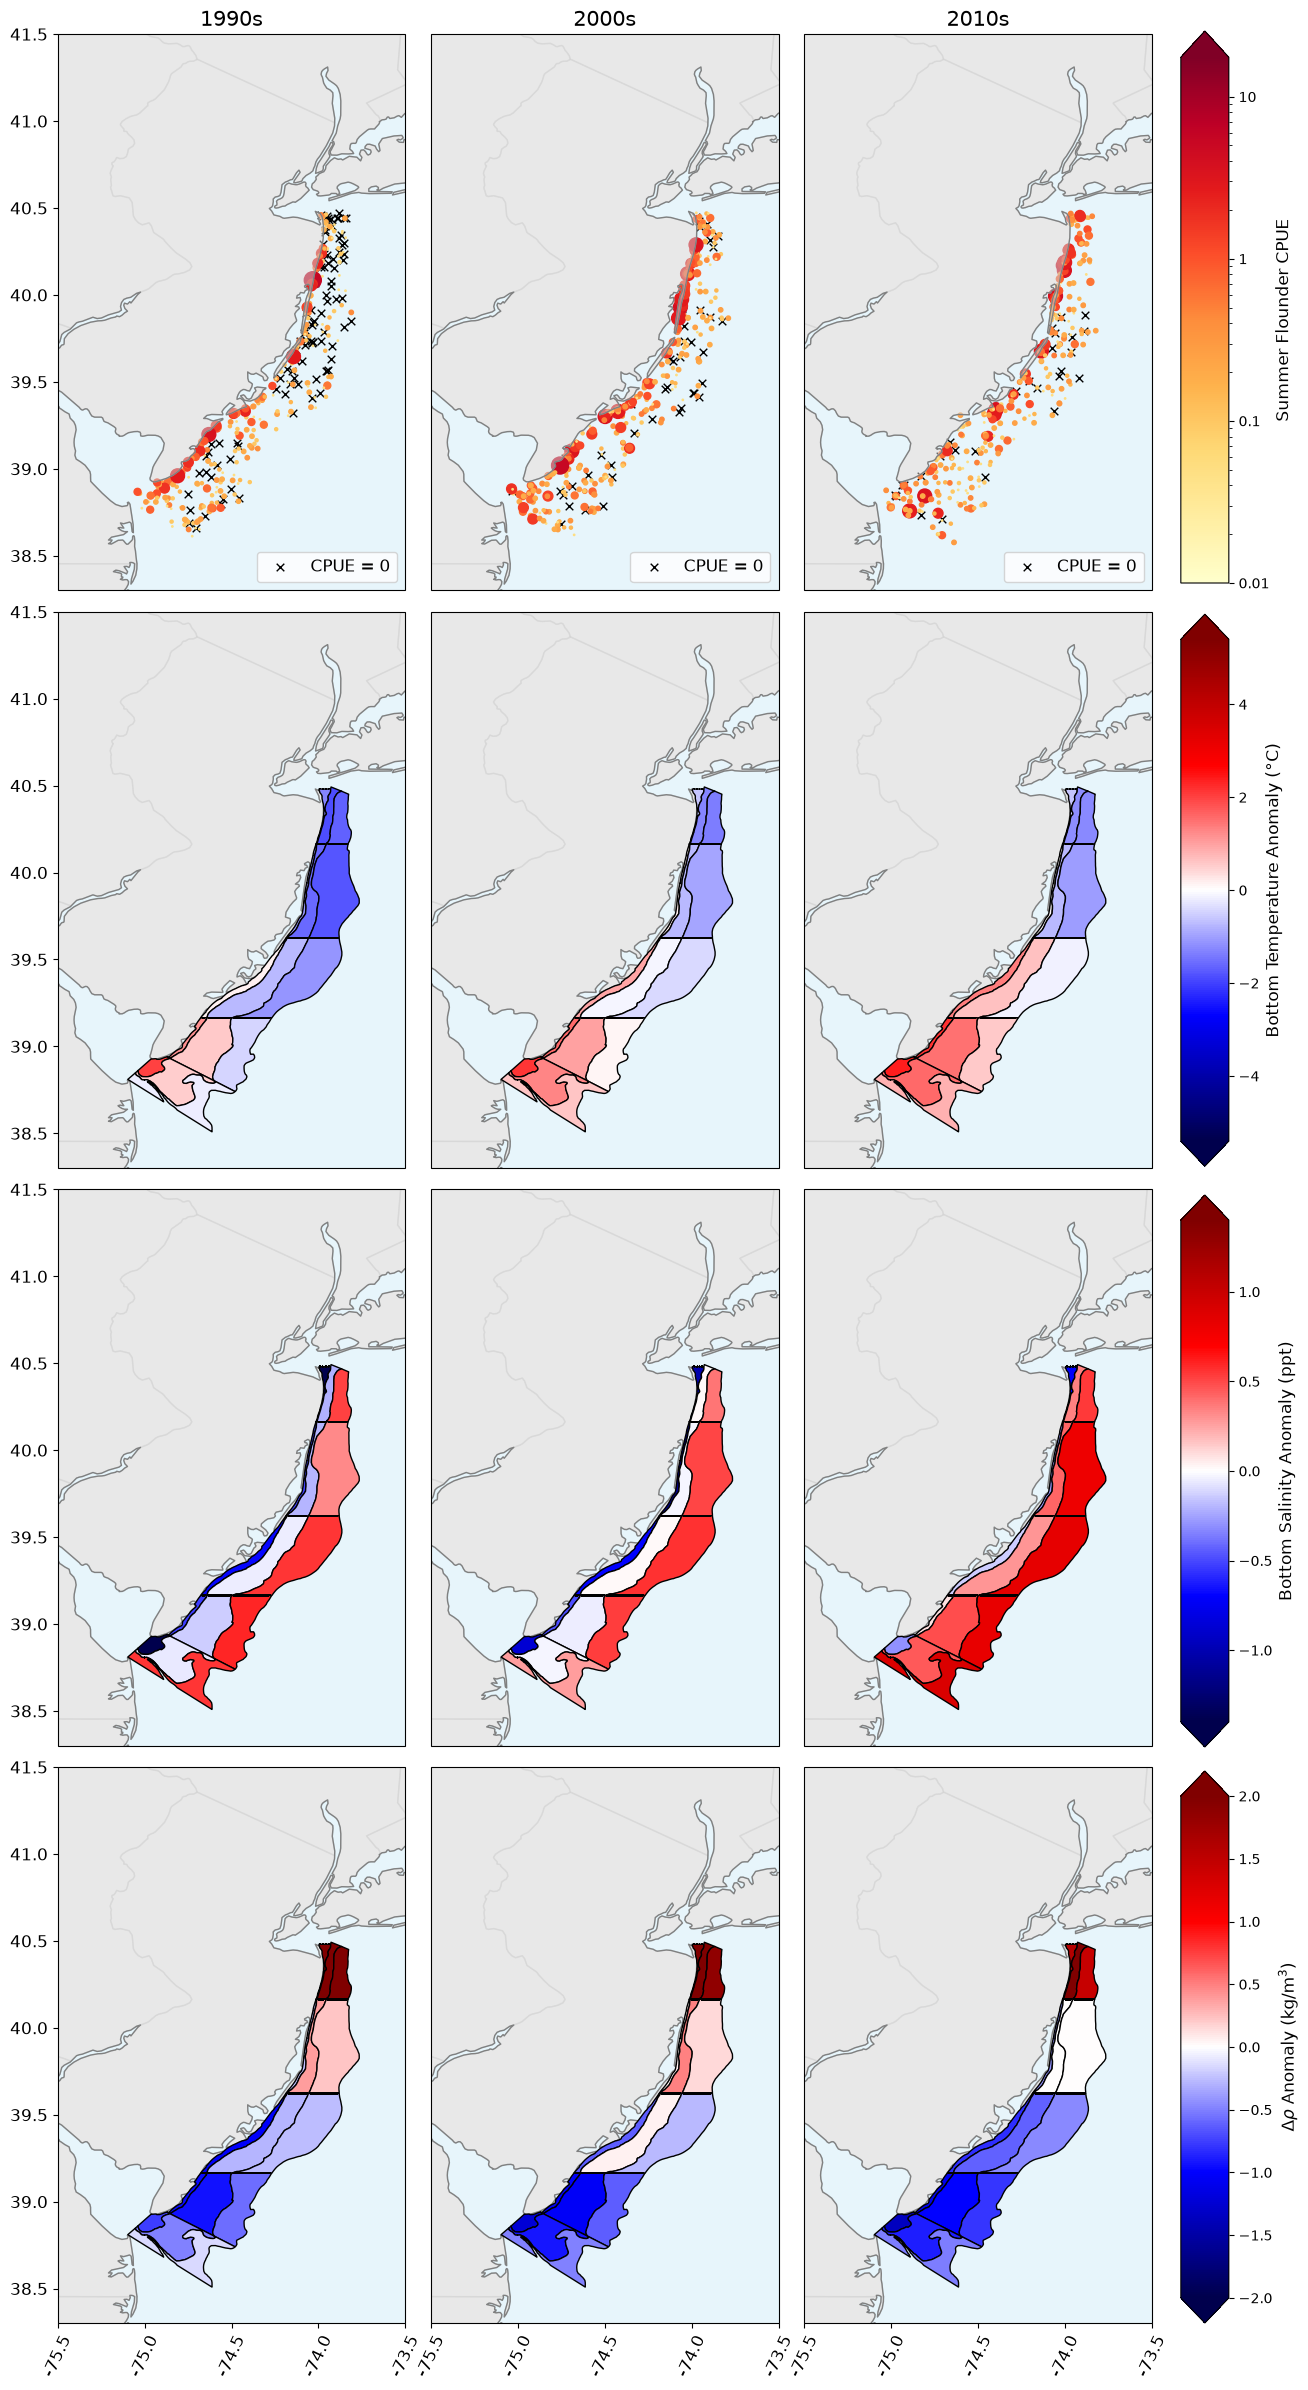

In [ ]:
## Anomalies By Decade
decades = [y90_april,y2k_april,y210_april]
decade_nj =[nj90_ap, nj00_ap,nj10_ap]
decade = ["1990s","2000s","2010s"]

fig, ax = plt.subplots(4,3,sharey=True,sharex=True,figsize=(24, 24), subplot_kw={'projection': ccrs.PlateCarree()}) #
extent = [-75.5, -73.5, 38.3, 41.5]


################################# Setting the Basemap for Each plot #################################
for i in range(4):  # Loop through rows
    for j in range(3):  # Loop through columns
        ax[i, j].add_feature(cfeature.STATES, color="lightgrey", alpha=0.5)
        ax[i, j].add_feature(cfeature.OCEAN, color="skyblue", alpha=0.2)
        ax[i, j].add_feature(cfeature.COASTLINE, color='grey')
        ax[i, j].set_extent(extent)

        # Enforce identical axis limits
        ax[i, j].set_xlim(extent[0], extent[1])
        ax[i, j].set_ylim(extent[2], extent[3])


        ax[3, j].set_xticks([-75.5, -75.0, -74.5, -74.0, -73.5]) 
        ax[3, j].set_xticklabels([-75.5, -75.0, -74.5, -74.0, -73.5], fontsize=12, rotation=65)  
        
        ax[i, 0].set_yticks([38.5, 39.0, 39.5, 40.0, 40.5, 41.0, 41.5])
        ax[i, 0].set_yticklabels([38.5, 39.0, 39.5, 40.0, 40.5, 41.0, 41.5], fontsize=12)

#####################################################################################################
        
########################################## Summer Flounder ##########################################
bin_edges = [0,0.05, 0.15, 0.55, 1.3,2.5, 5, 10,15,17.5]
size_labels = [1,5,10,25,50,100,150,225,250]
ticks = [0.01,0.1,1,10]
norm_para = mpl.colors.LogNorm(vmin=0.01,vmax=17.5)

for i in range(3):
    sizes = pd.cut(decades[i]['para_cpue'], bins=bin_edges, labels=size_labels, include_lowest=True).astype(float)
    
    zero_cpue = decades[i][decades[i]["para_cpue"] == 0]
    ax[0,i].scatter(zero_cpue["SLONG"], zero_cpue["SLAT"], marker='x', color='black', s=30, linewidths=1, label="CPUE = 0")
    
    sc = ax[0,i].scatter(decades[i]["SLONG"],decades[i]["SLAT"],c=decades[i]["para_cpue"],cmap="YlOrRd", norm=norm_para, s=sizes)
    ax[0,i].set_title(decade[i],fontsize=15)
    ax[0,i].legend(fontsize=12 ,loc='lower right')

cbar_ax0 = fig.add_axes([0.74, 0.755, 0.02, 0.23])  # [left, bottom, width, height]
cbar0 = fig.colorbar(sc,cax=cbar_ax0,orientation='vertical', extend='max')
cbar0.set_ticks(ticks)
cbar0.set_ticklabels(ticks)
cbar0.set_label("Summer Flounder CPUE", fontsize=12)
#####################################################################################################

####################################### Bottom Temperature ##########################################
norm_temp = colors.Normalize(vmin=-5.4, vmax=5.4)
cmap = plt.get_cmap('seismic')
for a in range(3):
    for i, geom in enumerate(nj.geometry):
        value = decade_nj[a].loc[i, 'temp_anom']
        color = cmap(norm_temp(value))
        ax[1,a].add_geometries([geom], crs=ccrs.PlateCarree(), facecolor=color, edgecolor='black', zorder=1000)

cbar_ax1 = fig.add_axes([0.74, 0.512, 0.02, 0.23])  # [left, bottom, width, height]
cbar1 = fig.colorbar(mpl.cm.ScalarMappable(cmap="seismic", norm=norm_temp), extend='both', cax=cbar_ax1)
cbar1.set_label("Bottom Temperature Anomaly (°C)", fontsize=12)
#####################################################################################################


####################################### Bottom Salinity #############################################
norm_sal = colors.Normalize(vmin=-1.4, vmax=1.4)
cmap = plt.get_cmap('seismic')
for a in range(3):
    for i, geom in enumerate(nj.geometry):
        value = decade_nj[a].loc[i, 'sal_anom']
        color = cmap(norm_sal(value))
        ax[2,a].add_geometries([geom], crs=ccrs.PlateCarree(), facecolor=color, edgecolor='black', zorder=1000)

cbar_ax2 = fig.add_axes([0.74, 0.27, 0.02, 0.23])  # [left, bottom, width, height] 
cbar2 = fig.colorbar(mpl.cm.ScalarMappable(cmap="seismic", norm=norm_sal),extend='both', cax=cbar_ax2)
cbar2.set_label("Bottom Salinity Anomaly (ppt)", fontsize=12)
######################################################################################################


############################################## delta Rho #############################################
norm_rho = colors.Normalize(vmin=-2, vmax=2)
cmap = plt.get_cmap('seismic')
for a in range(3):
    for i, geom in enumerate(nj.geometry):
        value = decade_nj[a].loc[i, 'deltarho_anom']
        color = cmap(norm_rho(value))
        ax[3,a].add_geometries([geom], crs=ccrs.PlateCarree(), facecolor=color, edgecolor='black', zorder=1000)
        
cbar_ax3 = fig.add_axes([0.74, 0.03, 0.02, 0.23])  
cbar3 = fig.colorbar(mpl.cm.ScalarMappable(cmap="seismic", norm=norm_rho),extend='both', cax=cbar_ax3)
cbar3.set_label(r"$\Delta\rho$ Anomaly (kg/m$^3$)", fontsize=12)
######################################################################################################

fig.subplots_adjust(wspace=-.9, hspace=0.2, right=0.9)

fig.tight_layout()

##### August

In [79]:
y90_aug = aug_cruise.groupby("decade").get_group(1990)
y2k_aug = aug_cruise.groupby("decade").get_group(2000)
y210_aug= aug_cruise.groupby("decade").get_group(2010)

In [80]:
aug90s_mean = y90_aug.groupby('STRATUM')[["para_cpue",'temp_anom',"sal_anom",'deltarho_anom']].mean()
aug00s_mean = y2k_aug.groupby('STRATUM')[["para_cpue",'temp_anom',"sal_anom",'deltarho_anom']].mean()
aug10s_mean = y210_aug.groupby('STRATUM')[["para_cpue",'temp_anom',"sal_anom",'deltarho_anom']].mean()
aug_mean = aug_cruise.groupby('STRATUM')[["para_cpue",'temp_anom',"sal_anom",'deltarho_anom']].std()

In [81]:
nj90_aug = nj.merge(aug90s_mean, on="STRATUM",how='left')
nj00_aug = nj.merge(aug00s_mean, on="STRATUM",how='left')
nj10_aug = nj.merge(aug10s_mean, on="STRATUM",how='left')
nj_augall = nj.merge(aug_mean, on="STRATUM",how='left')

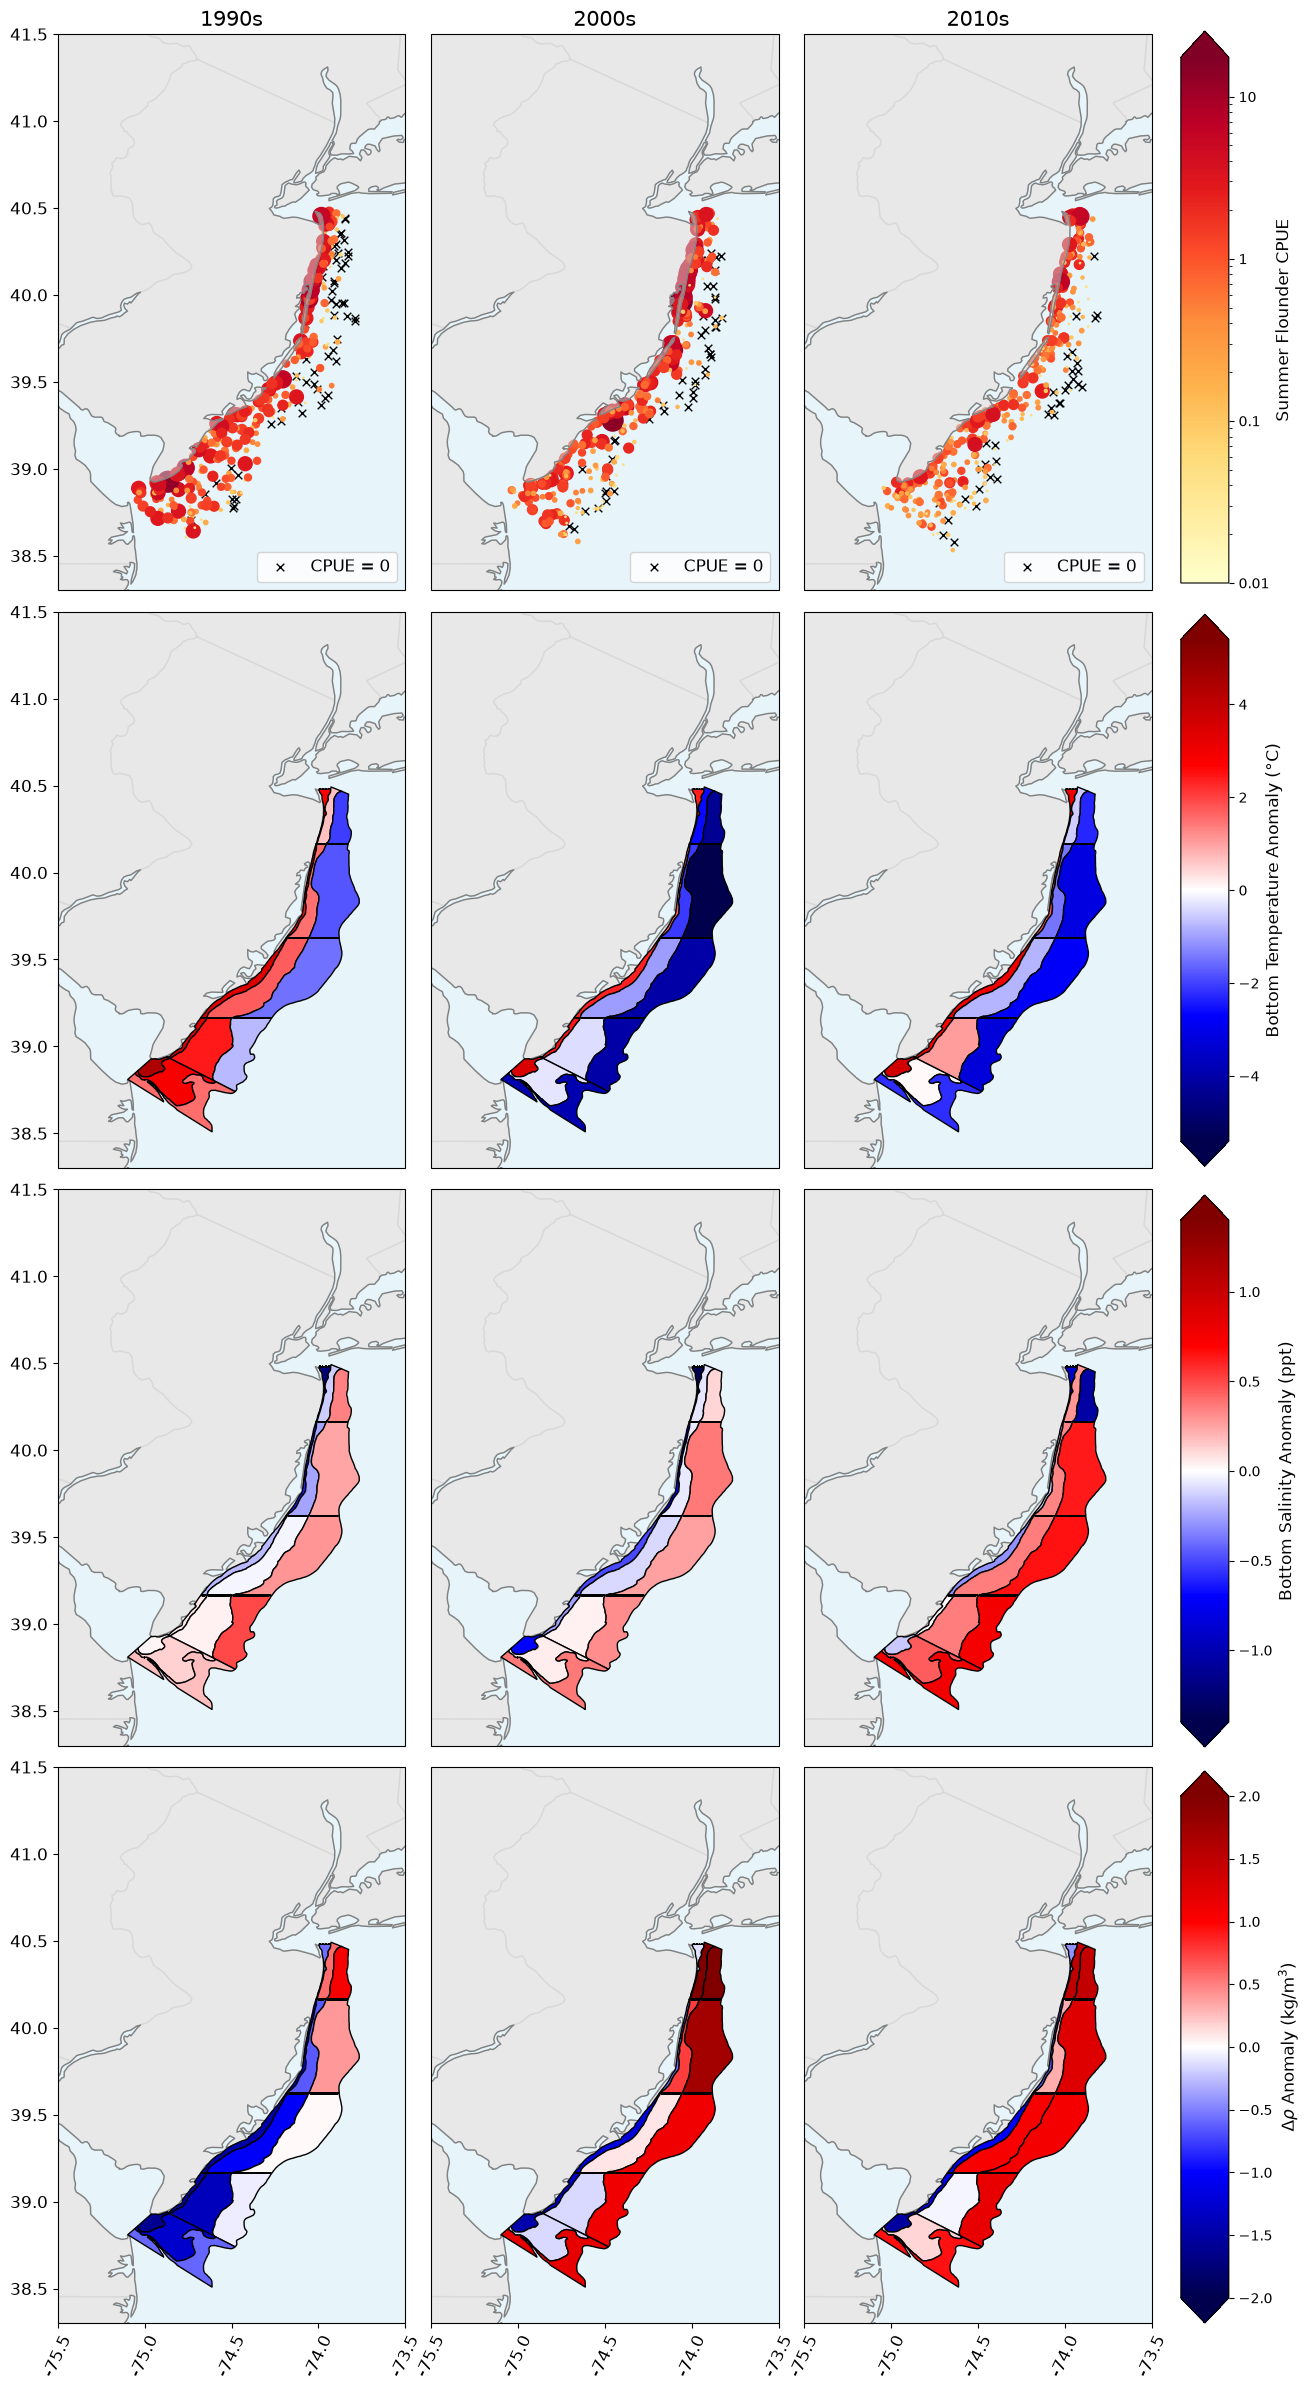

In [ ]:
## Anomalies By Decade
decades = [y90_aug,y2k_aug,y210_aug]
decade_nj =[nj90_aug, nj00_aug,nj10_aug]
decade = ["1990s","2000s","2010s"]

fig, ax = plt.subplots(4,3,sharey=True,sharex=True,figsize=(24, 24), subplot_kw={'projection': ccrs.PlateCarree()}) #
extent = [-75.5, -73.5, 38.3, 41.5]

################################# Setting the Basemap for Each plot #################################
for i in range(4):  # Loop through rows
    for j in range(3):  # Loop through columns
        ax[i, j].add_feature(cfeature.STATES, color="lightgrey", alpha=0.5)
        ax[i, j].add_feature(cfeature.OCEAN, color="skyblue", alpha=0.2)
        ax[i, j].add_feature(cfeature.COASTLINE, color='grey')
        ax[i, j].set_extent(extent)

        # Enforce identical axis limits
        ax[i, j].set_xlim(extent[0], extent[1])
        ax[i, j].set_ylim(extent[2], extent[3])


        ax[3, j].set_xticks([-75.5, -75.0, -74.5, -74.0, -73.5]) 
        ax[3, j].set_xticklabels([-75.5, -75.0, -74.5, -74.0, -73.5], fontsize=12, rotation=65)  
        
        ax[i, 0].set_yticks([38.5, 39.0, 39.5, 40.0, 40.5, 41.0, 41.5])
        ax[i, 0].set_yticklabels([38.5, 39.0, 39.5, 40.0, 40.5, 41.0, 41.5], fontsize=12)

#####################################################################################################
        
########################################## Summer Flounder ##########################################
bin_edges = [0,0.05, 0.15, 0.55, 1.3,2.5, 5, 10,15,17.5]
size_labels = [1,5,10,25,50,100,150,225,250]
ticks = [0.01,0.1,1,10]
norm_para = mpl.colors.LogNorm(vmin=0.01,vmax=17.5)

for i in range(3):
    sizes = pd.cut(decades[i]['para_cpue'], bins=bin_edges, labels=size_labels, include_lowest=True).astype(float)
    
    zero_cpue = decades[i][decades[i]["para_cpue"] == 0]
    ax[0,i].scatter(zero_cpue["SLONG"], zero_cpue["SLAT"], marker='x', color='black', s=30, linewidths=1, label="CPUE = 0")
    
    sc = ax[0,i].scatter(decades[i]["SLONG"],decades[i]["SLAT"],c=decades[i]["para_cpue"],cmap="YlOrRd", norm=norm_para, s=sizes)
    ax[0,i].set_title(decade[i],fontsize=15)
    ax[0,i].legend(fontsize=12 ,loc='lower right')

cbar_ax0 = fig.add_axes([0.74, 0.755, 0.02, 0.23])  # [left, bottom, width, height]
cbar0 = fig.colorbar(sc,cax=cbar_ax0,orientation='vertical', extend='max')
cbar0.set_ticks(ticks)
cbar0.set_ticklabels(ticks)
cbar0.set_label("Summer Flounder CPUE", fontsize=12)
#####################################################################################################

####################################### Bottom Temperature ##########################################
norm_temp = colors.Normalize(vmin=-5.4, vmax=5.4)
cmap = plt.get_cmap('seismic')
for a in range(3):
    for i, geom in enumerate(nj.geometry):
        value = decade_nj[a].loc[i, 'temp_anom']
        color = cmap(norm_temp(value))
        ax[1,a].add_geometries([geom], crs=ccrs.PlateCarree(), facecolor=color, edgecolor='black', zorder=1000)

cbar_ax1 = fig.add_axes([0.74, 0.512, 0.02, 0.23])  # [left, bottom, width, height]
cbar1 = fig.colorbar(mpl.cm.ScalarMappable(cmap="seismic", norm=norm_temp), extend='both', cax=cbar_ax1)
cbar1.set_label("Bottom Temperature Anomaly (°C)", fontsize=12)
#####################################################################################################


####################################### Bottom Salinity #############################################
norm_sal = colors.Normalize(vmin=-1.4, vmax=1.4)
cmap = plt.get_cmap('seismic')
for a in range(3):
    for i, geom in enumerate(nj.geometry):
        value = decade_nj[a].loc[i, 'sal_anom']
        color = cmap(norm_sal(value))
        ax[2,a].add_geometries([geom], crs=ccrs.PlateCarree(), facecolor=color, edgecolor='black', zorder=1000)

cbar_ax2 = fig.add_axes([0.74, 0.27, 0.02, 0.23])  # [left, bottom, width, height] 
cbar2 = fig.colorbar(mpl.cm.ScalarMappable(cmap="seismic", norm=norm_sal),extend='both', cax=cbar_ax2)
cbar2.set_label("Bottom Salinity Anomaly (ppt)", fontsize=12)
######################################################################################################


############################################## delta Rho #############################################
norm_rho = colors.Normalize(vmin=-2, vmax=2)
cmap = plt.get_cmap('seismic')
for a in range(3):
    for i, geom in enumerate(nj.geometry):
        value = decade_nj[a].loc[i, 'deltarho_anom']
        color = cmap(norm_rho(value))
        ax[3,a].add_geometries([geom], crs=ccrs.PlateCarree(), facecolor=color, edgecolor='black', zorder=1000)
        
cbar_ax3 = fig.add_axes([0.74, 0.03, 0.02, 0.23])  
cbar3 = fig.colorbar(mpl.cm.ScalarMappable(cmap="seismic", norm=norm_rho),extend='both', cax=cbar_ax3)
cbar3.set_label(r"$\Delta\rho$ Anomaly (kg/m$^3$)", fontsize=12)
######################################################################################################

fig.subplots_adjust(wspace=-.9, hspace=0.2, right=0.9)

fig.tight_layout()